# Classificação de asteróides

Instalação e importação de bibliotecas

In [ ]:
!pip install -q astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.4 MB/s eta 0:00:00


In [ ]:
from pyvo.dal.tap import TAPService
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import numpy as np

## Dados preliminares e preparação do DataFrame

Acesso ao banco de dados do Vizier

In [ ]:
identificadores = [41, 92, 129, 130, 201, 234, 762,
           779, 854, 1344, 1656, 1727, 1770,
           1798, 1803, 1879, 2019, 2178, 2337,
           2449, 2516, 2577, 2602, 2623, 2754,
           2881, 2883, 2966, 3076, 3169, 3187,
           3309, 3523, 3533, 3548, 3623, 3657,
           3669, 3782, 3841, 3865, 3873, 3959,
           4029, 4092, 4179, 4296, 4383, 4411,
           4450, 4514, 4541, 4605, 4607, 4765,
           4868, 5037, 5143, 5232, 5261, 5425,
           5481, 5500, 5536, 5646, 5674, 5772,
           5781, 5872, 5905, 6086, 6100, 6245,
           6265, 6611, 7002, 7088, 7132, 7307,
           7335, 7344, 7355, 7615, 7958, 8077,
           8116, 8474, 9260, 9474, 9783, 9940,
           9972, 10044, 10123, 10208, 11066,
           13920, 14469, 15094, 15107, 15268,
           15430, 15700, 15822, 16635, 16694,
           16974, 17081, 17246, 17251, 17260,
           18301, 18503, 18890, 20882, 21149,
           23621, 25015, 25143, 26420, 26471,
           27568, 27675, 29314, 31346, 31450,
           32008, 38079, 38628, 47171, 48470,
           52316, 57027, 57202, 65803, 66063,
           69230, 78085, 79360, 80218, 85804,
           85989, 85990, 90403, 90482, 100015,
           100624, 118303, 120347, 137126, 139775,
           144411, 152931, 185851, 192642, 236716,
           250162, 276049, 374851, 385458, 399774,
           415029, 418135, 450894, 461852, 481394,
           481532, 489486, 494658, 494999, 505447,
           505476, 506121, 523624, 523764, 523775,
           523804, 525816, 531074, 533562, 2, 3, 6,
           7, 16, 19, 28, 34, 40, 47, 55, 56, 57, 58,
           65, 66, 73, 74, 76, 77, 78, 81, 86, 95, 99,
           100, 101, 105, 106, 118, 119, 123, 126, 146,
           151, 156, 157, 159, 163, 164, 167, 176, 177,
           178, 181, 182, 183, 185, 188, 194, 196, 197,
           198, 202, 206, 207, 211, 212, 218, 219, 220,
           222, 225, 230, 232, 233, 239, 246, 248, 250,
           252, 258, 260, 264, 265, 267, 276, 280, 285,
           287, 294, 295, 296, 300, 304, 305, 306, 307,
           310, 313, 314, 318, 319, 320, 330, 333, 334,
           335, 338, 339, 341, 345, 346, 348, 349, 354,
           357, 358, 365, 371, 374, 386, 390, 392, 394,
           399, 405, 411, 412, 414, 416, 417, 423, 426,
           428, 429, 432, 437, 439, 440, 446, 448, 449,
           454, 455, 456, 460, 462, 467, 474, 480, 483,
           484, 491, 494, 496, 497, 507, 524, 572, 575,
           576, 578, 579, 581, 585, 590, 591, 598, 600,
           601, 605, 607, 614, 616, 619, 620, 630, 631,
           632, 633, 634, 635, 638, 640, 641, 642, 650,
           651, 653, 656, 660, 663, 664, 665, 667, 668,
           669, 671, 676, 680, 681, 682, 687, 688, 690,
           691, 700, 701, 706, 709, 713, 716, 719, 723,
           724, 725, 728]


tap = TAPService("https://tapvizier.cds.unistra.fr/TAPVizieR/tap")

in_clause = ",".join(str(n) for n in identificadores)

query = f'''
SELECT *
FROM "J/A+A/652/A59/sso"
WHERE "Number" IN ({in_clause})
'''

resultado = tap.run_sync(query)
tabela = resultado.to_table()

print(f"Total de observações encontradas: {len(tabela)}")
#print(tabela)

Total de observações encontradas: 845


In [ ]:
#print(tabela.info)        # nomes de colunas, dtypes, unidades
#print(tabela.colnames)

Construção do DataFrame com as features de interesse

In [ ]:
df = pd.DataFrame(resultado)

df

colunas = ['Number', 'Geodist', 'Heliodist', 'alpha', 'umag', 'gmag', 'rmag', 'imag', 'zmag']
novo_df = df[colunas].sort_values(by='Number')

novo_df.head()

,Number,Geodist,Heliodist,alpha,umag,gmag,rmag,imag,zmag
628,2,2.284025,3.218648,7.71,10.9725,9.4540,8.8835,14.3428,9.0442
419,3,1.444917,2.419905,4.30,11.4532,8.9992,13.8887,7.8415,8.2527
331,6,1.429158,1.989888,28.22,11.2338,9.6128,8.9439,8.7627,8.9306
618,7,1.095657,2.098627,5.18,10.6524,8.3668,14.8456,14.3222,7.6722
469,16,2.263771,3.205460,6.26,12.4846,11.2588,10.4860,10.2913,10.4179


In [ ]:
# repetidos = df['Number'].value_counts()
# print(repetidos[repetidos > 1])

In [ ]:
# unicos = novo_df['Number'].nunique()

# print(unicos)

Criação da variável alvo - *classe*

In [ ]:
novo_df['classe']=0
# novo_df

binarios = [2, 3, 6,
           7, 16, 19, 28, 34, 40, 47, 55, 56, 57, 58,
           65, 66, 73, 74, 76, 77, 78, 81, 86, 95, 99,
           100, 101, 105, 106, 118, 119, 123, 126, 146,
           151, 156, 157, 159, 163, 164, 167, 176, 177,
           178, 181, 182, 183, 185, 188, 194, 196, 197,
           198, 202, 206, 207, 211, 212, 218, 219, 220,
           222, 225, 230, 232, 233, 239, 246, 248, 250,
           252, 258, 260, 264, 265, 267, 276, 280, 285,
           287, 294, 295, 296, 300, 304, 305, 306, 307,
           310, 313, 314, 318, 319, 320, 330, 333, 334,
           335, 338, 339, 341, 345, 346, 348, 349, 354,
           357, 358, 365, 371, 374, 386, 390, 392, 394,
           399, 405, 411, 412, 414, 416, 417, 423, 426,
           428, 429, 432, 437, 439, 440, 446, 448, 449,
           454, 455, 456, 460, 462, 467, 474, 480, 483,
           484, 491, 494, 496, 497, 507, 524, 572, 575,
           576, 578, 579, 581, 585, 590, 591, 598, 600,
           601, 605, 607, 614, 616, 619, 620, 630, 631,
           632, 633, 634, 635, 638, 640, 641, 642, 650,
           651, 653, 656, 660, 663, 664, 665, 667, 668,
           669, 671, 676, 680, 681, 682, 687, 688, 690,
           691, 700, 701, 706, 709, 713, 716, 719, 723,
           724, 725, 728]

novo_df.loc[novo_df['Number'].isin(binarios), 'classe'] = 1

novo_df

,Number,Geodist,Heliodist,alpha,umag,gmag,rmag,imag,zmag,classe
628,2,2.284025,3.218648,7.71,10.9725,9.4540,8.8835,14.3428,9.0442,1
419,3,1.444917,2.419905,4.30,11.4532,8.9992,13.8887,7.8415,8.2527,1
331,6,1.429158,1.989888,28.22,11.2338,9.6128,8.9439,8.7627,8.9306,1
618,7,1.095657,2.098627,5.18,10.6524,8.3668,14.8456,14.3222,7.6722,1
469,16,2.263771,3.205460,6.26,12.4846,11.2588,10.4860,10.2913,10.4179,1
...,...,...,...,...,...,...,...,...,...,...
238,525816,35.271975,36.228369,0.44,22.7497,22.9479,22.1903,21.7989,21.4061,0
235,525816,35.295127,36.226933,0.55,23.7433,23.2121,22.1022,21.6319,22.2991,0
490,531074,35.366497,35.705579,1.49,24.6434,24.1144,22.6960,22.4746,22.0232,0
511,533562,29.960355,30.922162,0.54,25.5650,22.6269,21.9467,21.6169,21.5969,0


In [ ]:
print(novo_df.groupby("classe")["Number"].nunique())

classe
0    180
1    208
Name: Number, dtype: int64


In [ ]:
novo_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 845 entries, 628 to 512
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Number     845 non-null    int32  
 1   Geodist    845 non-null    float64
 2   Heliodist  845 non-null    float64
 3   alpha      845 non-null    float64
 4   umag       844 non-null    float64
 5   gmag       845 non-null    float64
 6   rmag       845 non-null    float64
 7   imag       845 non-null    float64
 8   zmag       845 non-null    float64
 9   classe     845 non-null    int64  
dtypes: float64(8), int32(1), int64(1)
memory usage: 69.3 KB


In [ ]:
print(novo_df[novo_df['umag'].isna()][['Number', 'umag', 'classe']])

     Number  umag  classe
249     579   NaN       1


In [ ]:
print(novo_df[novo_df['Number']==579])

     Number   Geodist  Heliodist  alpha     umag     gmag     rmag     imag  \
249     579  1.979037   2.924822   7.90      NaN  25.1144  24.8020  24.3618   
180     579  1.986762   2.946836   6.14  23.9344  22.4060  21.3643  20.6890   

        zmag  classe  
249  22.8269       1  
180  20.3037       1  


In [ ]:
novo_df = novo_df.dropna(subset=['umag']).reset_index(drop=True)
novo_df.head()

,Number,Geodist,Heliodist,alpha,umag,gmag,rmag,imag,zmag,classe
0,2,2.284025,3.218648,7.71,10.9725,9.4540,8.8835,14.3428,9.0442,1
1,3,1.444917,2.419905,4.30,11.4532,8.9992,13.8887,7.8415,8.2527,1
2,6,1.429158,1.989888,28.22,11.2338,9.6128,8.9439,8.7627,8.9306,1
3,7,1.095657,2.098627,5.18,10.6524,8.3668,14.8456,14.3222,7.6722,1
4,16,2.263771,3.205460,6.26,12.4846,11.2588,10.4860,10.2913,10.4179,1


In [ ]:
novo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844 entries, 0 to 843
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Number     844 non-null    int32  
 1   Geodist    844 non-null    float64
 2   Heliodist  844 non-null    float64
 3   alpha      844 non-null    float64
 4   umag       844 non-null    float64
 5   gmag       844 non-null    float64
 6   rmag       844 non-null    float64
 7   imag       844 non-null    float64
 8   zmag       844 non-null    float64
 9   classe     844 non-null    int64  
dtypes: float64(8), int32(1), int64(1)
memory usage: 62.8 KB


## Agrupamento e Estratificação

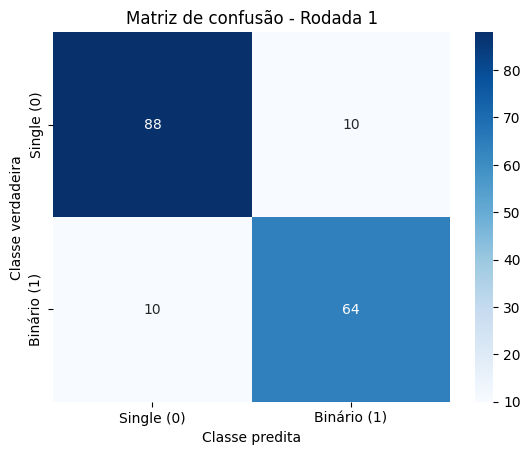

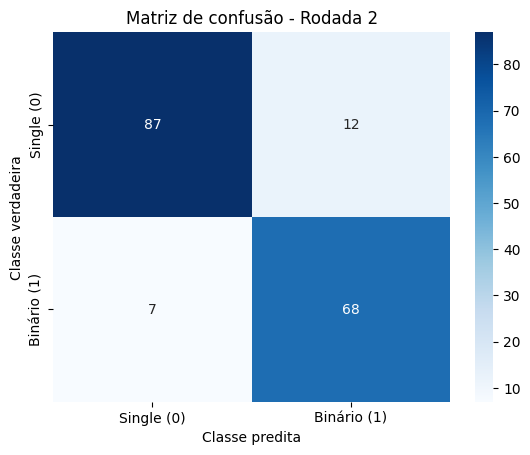

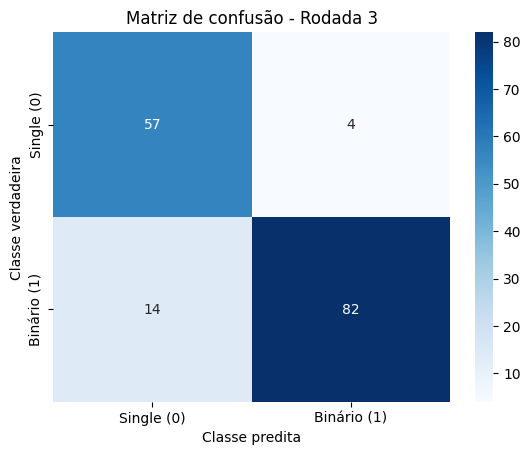

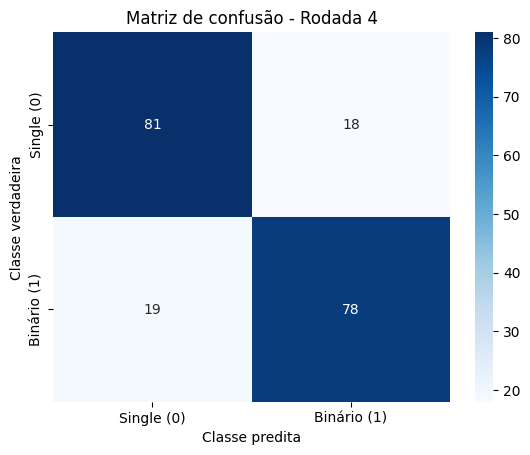

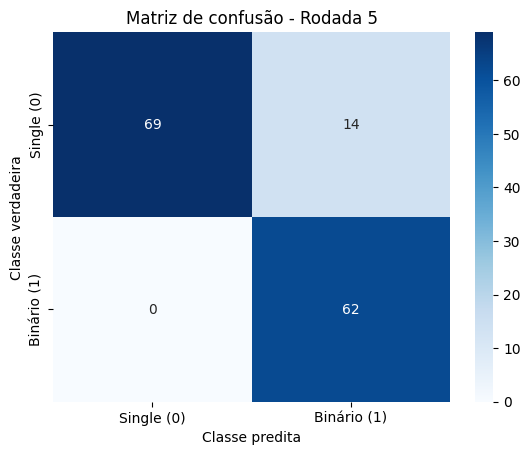

In [ ]:
modelo = LogisticRegression()

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

X = novo_df[['Geodist', 'Heliodist', 'alpha', 'umag', 'gmag', 'rmag', 'imag', 'zmag']]
y = novo_df['classe']

groups = novo_df['Number']

acuracias = []
precisoes = []
recalls = []
f1s = []
for rodada, (train_idx, test_idx) in enumerate(cv.split(X, y, groups), start = 1):
  X_train = X.iloc[train_idx]
  X_test = X.iloc[test_idx]

  y_train = y.iloc[train_idx]
  y_test = y.iloc[test_idx]

  scaler = StandardScaler()

  X_train_padronizado = scaler.fit_transform(X_train)
  X_test_padronizado = scaler.transform(X_test)

  modelo.fit(X_train_padronizado, y_train)

  y_pred = modelo.predict(X_test_padronizado)

  # print(f"Classe verdadeira: {y_test.values}")
  # print(f"Classe predita: {y_pred}")
  # print(f"Rodada {rodada}")

  matriz_confusao = confusion_matrix(y_test, y_pred)
  #print(matriz_confusao)
  sns.heatmap(matriz_confusao, annot=True, fmt="d", cmap='Blues', xticklabels=['Single (0)', 'Binário (1)'], yticklabels=['Single (0)', 'Binário (1)'])
  plt.xlabel("Classe predita")
  plt.ylabel("Classe verdadeira")
  plt.title(f"Matriz de confusão - Rodada {rodada}")
  plt.show()

  acuracia = accuracy_score(y_test, y_pred)
  acuracias.append(acuracia)

  precisao = precision_score(y_test, y_pred)
  precisoes.append(precisao)

  recall = recall_score(y_test, y_pred)
  recalls.append(recall)

  f1 = f1_score(y_test, y_pred)
  f1s.append(f1)
  #print(f"Rodada: {rodada}, Acurácia: {acuracia:.2%}")

  # treino_asteroides = (novo_df.loc[train_idx, ['Number', 'classe']].drop_duplicates('Number'))
  # teste_asteroides = (novo_df.loc[test_idx, ['Number', 'classe']].drop_duplicates('Number'))

  # print(f'Rodada {rodada}')
  # print('Asteroides no treino:', X_train['Number'].nunique())
  # print('Asteroides no teste:', X_test['Number'].nunique())

  # print('Proporção no treino:')
  # print(y_train.value_counts(normalize=True))

  # print("\nProporção no teste:")
  # print(y_test.value_counts(normalize=True))

  # print('Proporção por asteroide - treino:')
  # print(treino_asteroides['classe'].value_counts(normalize=True))

  # print("\nProporção por asteroide - teste:")
  # print(teste_asteroides['classe'].value_counts(normalize=True))

In [ ]:
media_acuracia = sum(acuracias) / len(acuracias)
media_precisao = sum(precisoes) / len(precisoes)
media_recall = sum(recalls) / len(recalls)
media_f1 = sum(f1s) / len(f1s)

print(f"Precisões das rodadas: {precisoes}")
print(f"Recalls das rodadas: {recalls}")
print(f"F1 das rodadas: {f1s}")


print(f"Média acuracia: {media_acuracia}, Média precisão: {media_precisao}, Média recall: {media_recall}, Média f1: {media_f1}")

Precisões das rodadas: [0.8648648648648649, 0.85, 0.9534883720930233, 0.8125, 0.8157894736842105]
Recalls das rodadas: [0.8648648648648649, 0.9066666666666666, 0.8541666666666666, 0.8041237113402062, 1.0]
F1 das rodadas: [0.8648648648648649, 0.8774193548387097, 0.9010989010989011, 0.8082901554404145, 0.8985507246376812]
Média acuracia: 0.8749097224126064, Média precisão: 0.8593285421284197, Média recall: 0.8859643819076808, Média f1: 0.8700448001761142


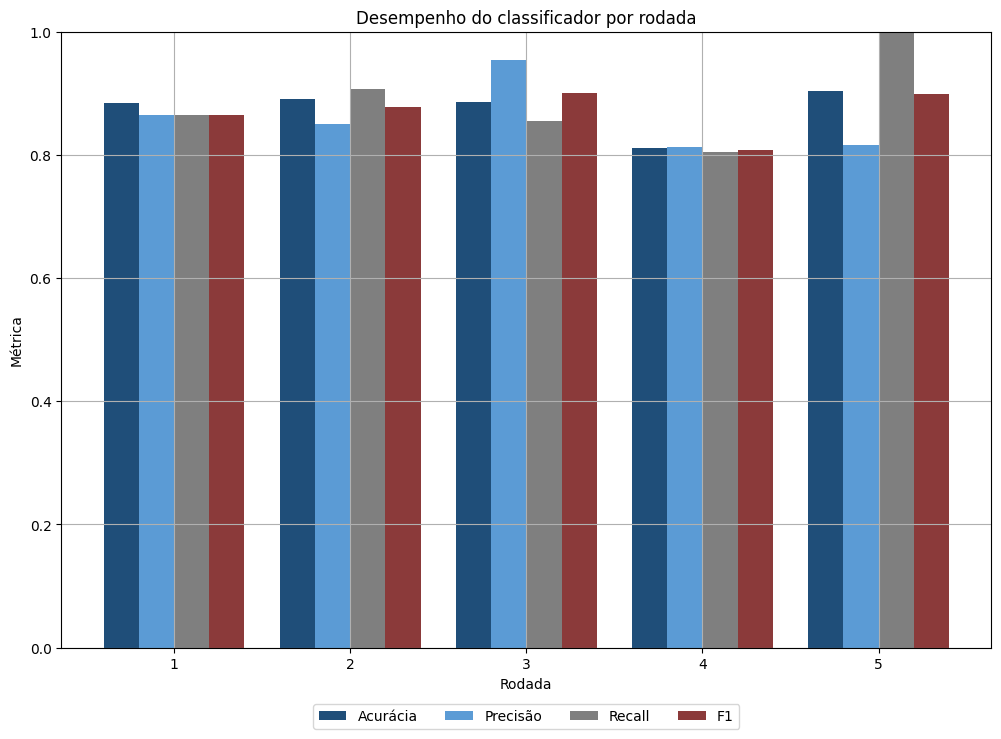

In [ ]:
plt.figure(figsize=(12, 8))

rodadas = range(1, 6)
largura = 0.2

plt.bar([x - 0.3 for x in rodadas], acuracias,
        width=largura, label='Acurácia',color='#1F4E79')

plt.bar([x - 0.1 for x in rodadas], precisoes,
        width=largura, label='Precisão',color='#5B9BD5')

plt.bar([x + 0.1 for x in rodadas], recalls,
        width=largura, label='Recall',color='#7F7F7F')

plt.bar([x + 0.3 for x in rodadas], f1s,
        width=largura, label='F1',color='#8B3A3A')

plt.xlabel('Rodada')
plt.ylabel('Métrica')
plt.title('Desempenho do classificador por rodada')

plt.xticks(range(1, 6))
plt.ylim(0, 1)

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=4
)
plt.grid(True)
plt.show()

In [ ]:
print(f"Acuracia: {np.mean(acuracias):.2%} +/- {np.std(acuracias):.2%}")

print(f"Precisão: {np.mean(precisoes):.2%} +/- {np.std(precisoes):.2%}")

print(f"Recall: {np.mean(recalls):.2%} +/- {np.std(recalls):.2%}")

print(f"F1: {np.mean(f1s):.2%} +/- {np.std(f1s):.2%}")

Acuracia: 87.49% +/- 3.26%
Precisão: 85.93% +/- 5.11%
Recall: 88.60% +/- 6.57%
F1: 87.00% +/- 3.37%


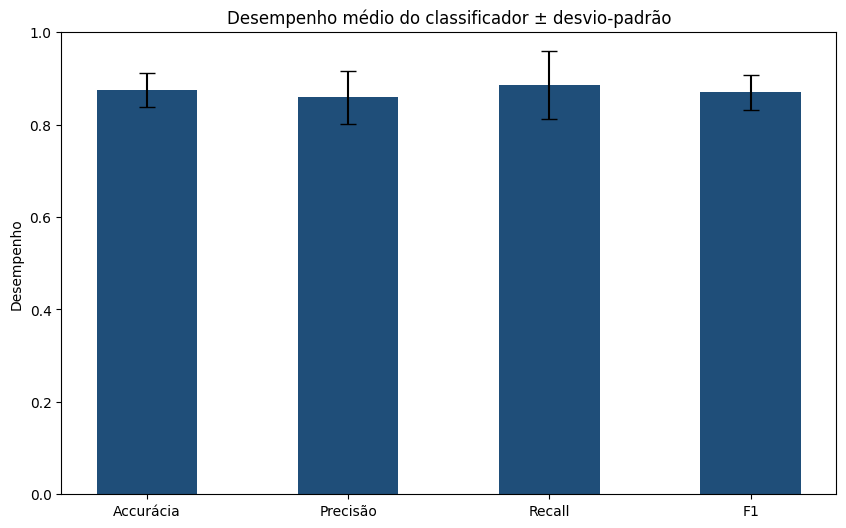

In [ ]:
metricas = ['Accurácia', 'Precisão', 'Recall', 'F1']

medias = [
    np.mean(acuracias),
    np.mean(precisoes),
    np.mean(recalls),
    np.mean(f1s)
]

desvios = [
    np.std(acuracias, ddof=1),
    np.std(precisoes, ddof=1),
    np.std(recalls, ddof=1),
    np.std(f1s, ddof=1)
]

plt.figure(figsize=(10, 6))

plt.bar(
    metricas,
    medias,
    yerr=desvios,
    capsize=6,
    width = 0.5,
    color='#1F4E79'
)

plt.ylabel('Desempenho')
plt.title('Desempenho médio do classificador ± desvio-padrão')

plt.ylim(0, 1)

plt.show()

## Análise Exploratória com PCA

In [ ]:
features = [
    'Geodist', 'Heliodist', 'alpha', 'umag', 'gmag', 'rmag', 'imag', 'zmag'
]

X_pca = novo_df[features]
scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X_pca)

pca = PCA()

X_pca = pca.fit_transform(X_padronizado)



In [ ]:
print(pca.explained_variance_ratio_)

[6.72804993e-01 2.15099627e-01 7.67468421e-02 2.17279072e-02
 6.20384670e-03 4.10922872e-03 3.27871837e-03 2.88369673e-05]


In [ ]:
variancia_acumulada = pca.explained_variance_ratio_.cumsum()
print(variancia_acumulada)

[0.67280499 0.88790462 0.96465146 0.98637937 0.99258322 0.99669244
 0.99997116 1.        ]


                PC1       PC2       PC3       PC4       PC5       PC6  \
Geodist    0.291727 -0.509382  0.391961  0.075419  0.007509  0.000564   
Heliodist  0.290722 -0.515973  0.374026  0.073583  0.009129 -0.000614   
alpha     -0.051063  0.583730  0.805613  0.078890 -0.034669 -0.003819   
umag       0.410372  0.179111 -0.068328 -0.080003  0.729906 -0.431700   
gmag       0.396463  0.169292 -0.181874  0.633450 -0.439308 -0.133553   
rmag       0.409716  0.126786 -0.035560 -0.519943 -0.477947 -0.460594   
imag       0.411830  0.139748 -0.033550 -0.438624 -0.047458  0.686783   
zmag       0.405845  0.192915 -0.131612  0.335086  0.205470  0.334612   

                PC7       PC8  
Geodist    0.005703 -0.704283  
Heliodist  0.006718  0.709798  
alpha     -0.005418  0.013045  
umag      -0.263279 -0.000851  
gmag      -0.411086  0.000274  
rmag       0.322294 -0.000311  
imag      -0.378716  0.000848  
zmag       0.717138 -0.000518  


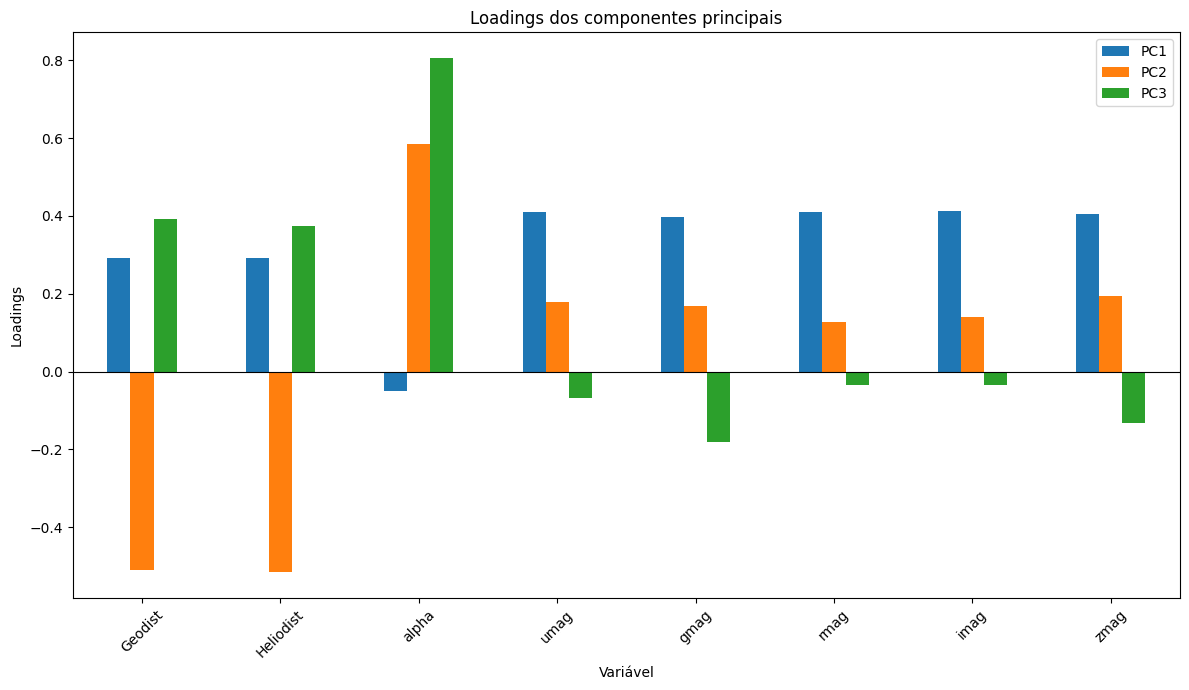

In [ ]:
loadingss = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(8)],
    index=features
)

print(loadingss)

loadingss[['PC1', 'PC2', 'PC3']].plot(
    kind='bar',
    figsize=(12, 7)
)

plt.ylabel('Loadings')
plt.xlabel('Variável')
plt.title('Loadings dos componentes principais')

plt.axhline(0, color='black', linewidth=0.8)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

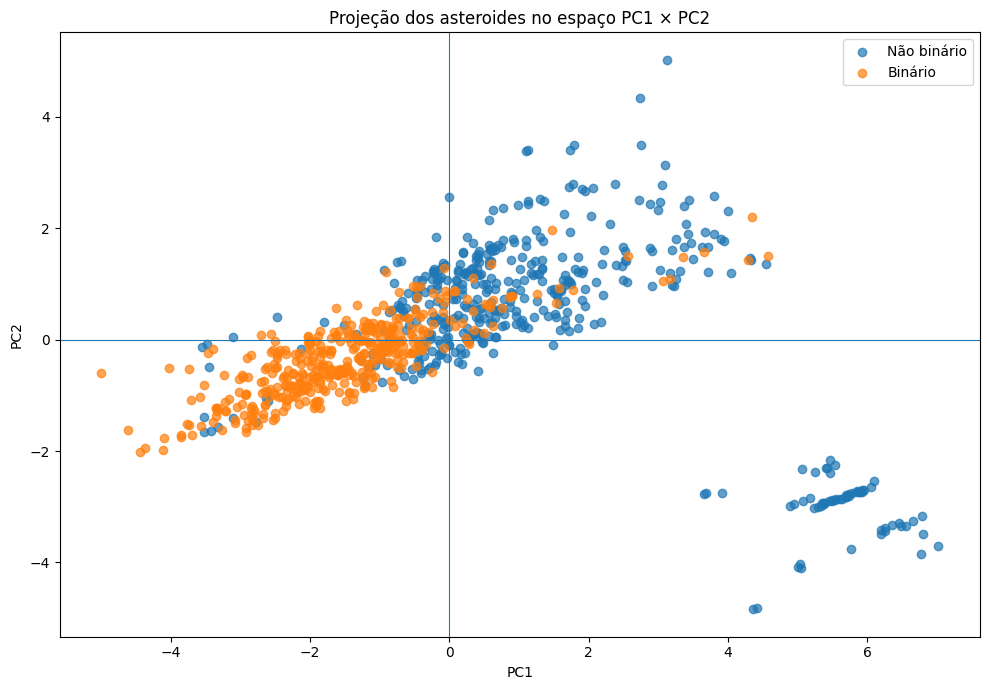

In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[y == 0, 0],
    X_pca[y == 0, 1],
    label='Não binário',
    alpha=0.7
)

plt.scatter(
    X_pca[y == 1, 0],
    X_pca[y == 1, 1],
    label='Binário',
    alpha=0.7
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Projeção dos asteroides no espaço PC1 × PC2')
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.legend()
plt.tight_layout()
plt.show()

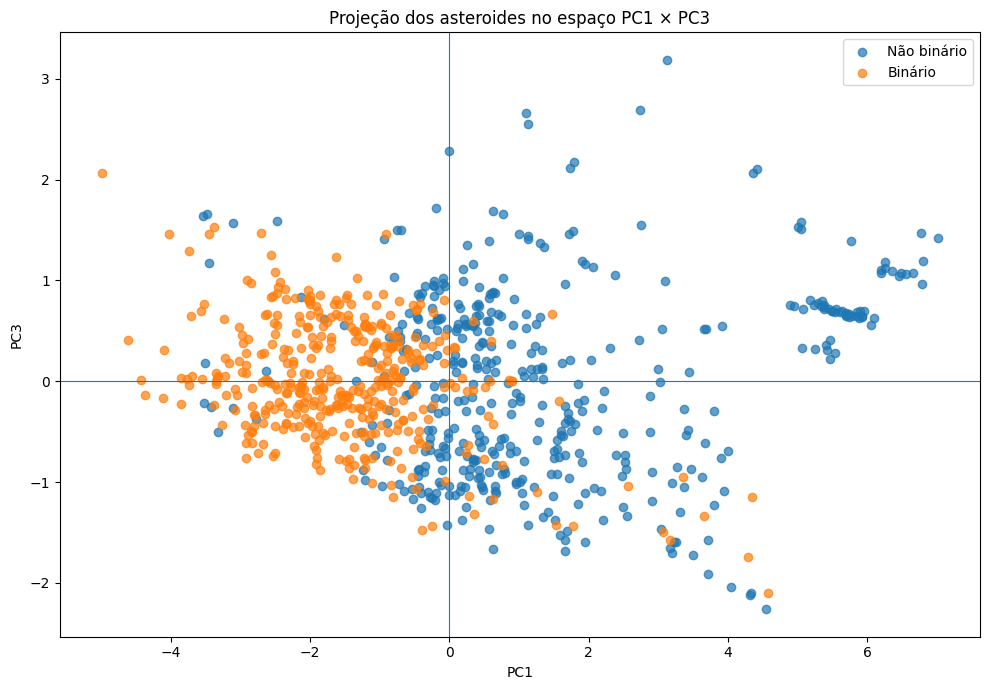

In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[y == 0, 0],
    X_pca[y == 0, 2],
    label='Não binário',
    alpha=0.7
)

plt.scatter(
    X_pca[y == 1, 0],
    X_pca[y == 1, 2],
    label='Binário',
    alpha=0.7
)

plt.xlabel('PC1')
plt.ylabel('PC3')
plt.title('Projeção dos asteroides no espaço PC1 × PC3')

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
variaveis = [
    'Geodist',
    'Heliodist',
    'alpha',
    'umag',
    'gmag',
    'rmag',
    'imag',
    'zmag'
]

matriz_corr = novo_df[variaveis].corr()

matriz_corr

,Geodist,Heliodist,alpha,umag,gmag,rmag,imag,zmag
Geodist,1.000000,0.999630,-0.396951,0.470102,0.438444,0.516693,0.510275,0.441071
Heliodist,0.999630,1.000000,-0.412190,0.466696,0.436138,0.513583,0.506931,0.438052
alpha,-0.396951,-0.412190,1.000000,0.031069,-0.019356,-0.009138,0.004626,0.021235
umag,0.470102,0.466696,0.031069,1.000000,0.915527,0.939778,0.951379,0.954493
gmag,0.438444,0.436138,-0.019356,0.915527,1.000000,0.866932,0.877083,0.960157
rmag,0.516693,0.513583,-0.009138,0.939778,0.866932,1.000000,0.966585,0.905797
imag,0.510275,0.506931,0.004626,0.951379,0.877083,0.966585,1.000000,0.923116
zmag,0.441071,0.438052,0.021235,0.954493,0.960157,0.905797,0.923116,1.000000


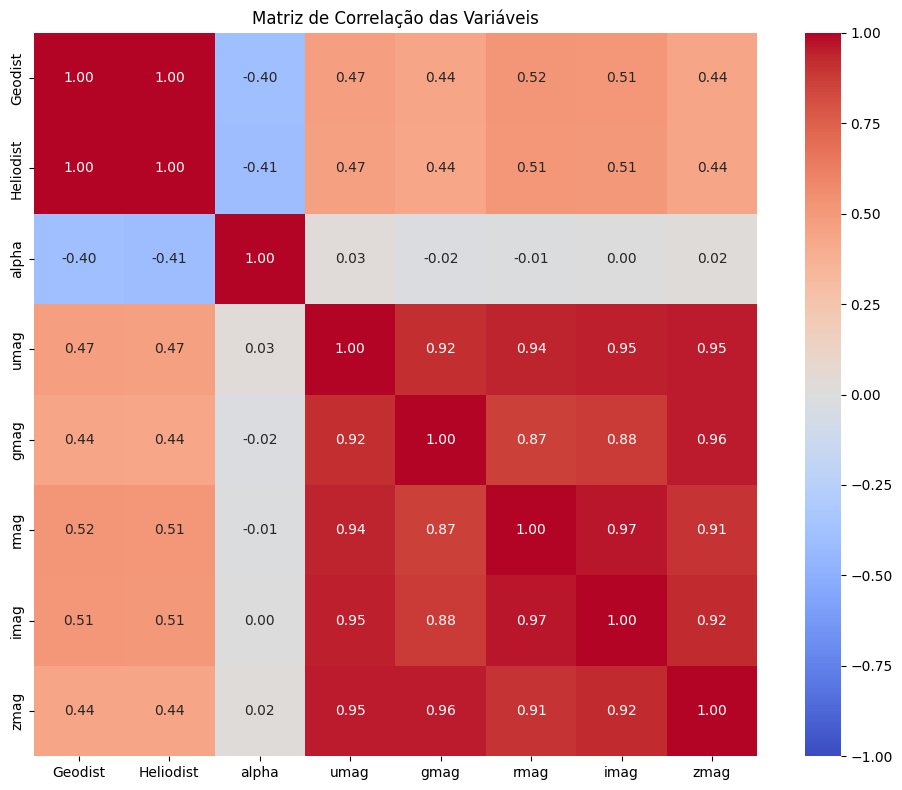

In [ ]:
variaveis = [
    'Geodist',
    'Heliodist',
    'alpha',
    'umag',
    'gmag',
    'rmag',
    'imag',
    'zmag'
]

matriz_corr = novo_df[variaveis].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    square=True
)

plt.title('Matriz de Correlação das Variáveis')
plt.tight_layout()
plt.show()

In [ ]:
coeficientes = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': modelo.coef_[0]
})

print(coeficientes)

     Feature  Coeficiente
0    Geodist     0.732039
1  Heliodist    -0.751614
2      alpha    -0.185769
3       umag    -2.281072
4       gmag     0.214203
5       rmag     0.023845
6       imag    -0.369692
7       zmag    -0.039276


In [ ]:
coeficientes['Importancia'] = coeficientes['Coeficiente'].abs()

coeficientes = coeficientes.sort_values(
    by='Importancia',
    ascending=True
)

print(coeficientes)

     Feature  Coeficiente  Importancia
5       rmag     0.023845     0.023845
7       zmag    -0.039276     0.039276
2      alpha    -0.185769     0.185769
4       gmag     0.214203     0.214203
6       imag    -0.369692     0.369692
0    Geodist     0.732039     0.732039
1  Heliodist    -0.751614     0.751614
3       umag    -2.281072     2.281072


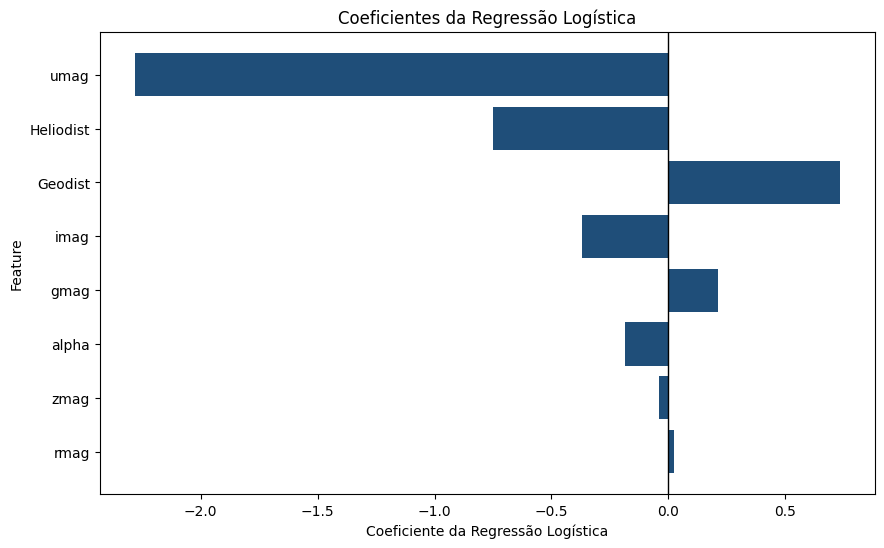

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    coeficientes['Feature'],
    coeficientes['Coeficiente'],
    color='#1F4E79'
)

plt.axvline(0, color='black', linewidth=1)

plt.xlabel('Coeficiente da Regressão Logística')
plt.ylabel('Feature')
plt.title('Coeficientes da Regressão Logística')

plt.show()